# SIBI Dynamic Point-History Classifier (Phase 2F)

Trains an LSTM (following Kazuhito Takahashi's `point_history_classification` reference) that maps a 32-step wrist trajectory (32 × 2 = 64 floats) to one of the dynamic SIBI classes — word gestures (jeruk, kucing, besar, kecil, sangat) plus the motion-letters J and Z.

**Data shape**: each sample is 32 points sampled UNIFORMLY along a fixed 1.5-second window (wall-clock). The frontend recorder collects raw timestamped wrist positions over that window, then linear-interpolates them to 32 evenly-spaced output points. This decouples the trained model from the recording laptop's MediaPipe inference rate — a "jeruk" gesture has the same temporal shape whether collected on a 30fps machine or a 10fps one.

**Older CSVs collected before the time-resample migration** (raw 32 consecutive frames, variable wall-clock duration) are NOT compatible with this dataset and should be cleared / re-collected.

Input CSV: `point_history_csv/dynamic.csv` (collected via `/dev/gesture-recorder` or `frontend/public/recorder.html`).
Output: `point_history_classifier.hdf5`, `point_history_classifier.tflite`.

In [13]:
import csv
import os
# Cap TF native threads BEFORE importing tf — improves stability on
# weaker CPUs. Required env vars are read only at first import.
os.environ.setdefault('TF_NUM_INTEROP_THREADS', '2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS', '4')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')  # silence INFO/WARN

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
FEATURE_LENGTH = 64  # 32 frames * 2 coords (must match DYNAMIC_HISTORY_SIZE in frontend recording/types.ts)
CSV_PATH = 'point_history_csv/dynamic.csv'
LABEL_CSV_PATH = 'point_history_csv/dynamic_label.csv'
MODEL_PATH = 'point_history_classifier.keras'
# SavedModel dir is what convert_to_tfjs.sh consumes. We skip the .tflite
# intermediate because TFLiteConverter crashes on LSTM in some TF 2.16+
# envs — SavedModel → TFJS path doesn't hit that bug.
SAVED_MODEL_DIR = 'point_history_classifier_saved_model'

In [14]:
df = pd.read_csv(CSV_PATH)
print(f'Total samples: {len(df)}')
print(f'Samples per class:\n{df["label"].value_counts()}')

# Derive label set + NUM_CLASSES from the actual data instead of a hardcoded
# constant — sorted for stable argmax-index mapping across runs. Writes back
# to LABEL_CSV_PATH so convert_to_tfjs.sh emits a labels.json that matches
# the trained model's softmax order.
labels = sorted(df['label'].astype(str).unique().tolist())
NUM_CLASSES = len(labels)
print(f'Derived {NUM_CLASSES} classes from data: {labels}')

pd.Series(labels).to_csv(LABEL_CSV_PATH, index=False, header=False)
print(f'Wrote {LABEL_CSV_PATH} with {NUM_CLASSES} class names.')

label_to_idx = {l: i for i, l in enumerate(labels)}
X = df.iloc[:, 1:].astype(np.float32).values
y_strings = df['label'].astype(str).values
y = np.array([label_to_idx[l] for l in y_strings], dtype=np.int32)
assert X.shape[1] == FEATURE_LENGTH, f'Expected {FEATURE_LENGTH} features, got {X.shape[1]}'
print(f'X shape: {X.shape}, y shape: {y.shape}')

Total samples: 809
Samples per class:
label
j               102
belajar         101
terima_kasih    101
tolong          101
maaf            101
yang            101
seperti         101
z               101
Name: count, dtype: int64
Derived 8 classes from data: ['belajar', 'j', 'maaf', 'seperti', 'terima_kasih', 'tolong', 'yang', 'z']
Wrote point_history_csv/dynamic_label.csv with 8 class names.
X shape: (809, 64), y shape: (809,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=RANDOM_SEED, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 606, Test: 203


In [16]:
# LSTM variant from Kazuhito's point_history_classification.ipynb.
# Reshape the flat (TIME_STEPS * DIMENSION,) feature vector into a proper
# (TIME_STEPS, DIMENSION) sequence so the LSTM can capture temporal order —
# critical for motion words like jeruk/kucing vs. their reverse-direction twins.
TIME_STEPS = 32  # = DYNAMIC_HISTORY_SIZE
DIMENSION = 2  # (x, y) per frame
assert TIME_STEPS * DIMENSION == FEATURE_LENGTH

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(FEATURE_LENGTH,)),
    tf.keras.layers.Reshape((TIME_STEPS, DIMENSION), input_shape=(FEATURE_LENGTH,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(16, input_shape=[TIME_STEPS, DIMENSION]),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

/home/arielsulton/Documents/Stargazing Project/VScode Project/tunarasa_ws/pensyarat/training/.venv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/arielsulton/Documents/Stargazing Project/VScode Project/tunarasa_ws/pensyarat/training/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/arielsulton/Documents/Stargazing Project/VScode Project/tunarasa_ws/pensyarat/training/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__in

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 32, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            88 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,474 (5.76 KB)

 Trainable params: 1,474 (5.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH, verbose=1, save_weights_only=False, save_best_only=True,
)
# Smaller patience + epoch cap so a flaky env doesn't run for hours before
# any potential crash. LSTM on 305 train samples converges within ~200 epochs.
es_callback = tf.keras.callbacks.EarlyStopping(patience=200, verbose=1, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,           # smaller batch — less memory pressure
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
    verbose=2,
)

Epoch 1/500



Epoch 1: val_loss improved from None to 2.07432, saving model to point_history_classifier.keras
19/19 - 6s - 334ms/step - accuracy: 0.1106 - loss: 2.0816 - val_accuracy: 0.1084 - val_loss: 2.0743
Epoch 2/500

Epoch 2: val_loss improved from 2.07432 to 2.07011, saving model to point_history_classifier.keras
19/19 - 1s - 30ms/step - accuracy: 0.1056 - loss: 2.0797 - val_accuracy: 0.1675 - val_loss: 2.0701
Epoch 3/500

Epoch 3: val_loss improved from 2.07011 to 2.06599, saving model to point_history_classifier.keras
19/19 - 1s - 47ms/step - accuracy: 0.1073 - loss: 2.0757 - val_accuracy: 0.1527 - val_loss: 2.0660
Epoch 4/500

Epoch 4: val_loss improved from 2.06599 to 2.06164, saving model to point_history_classifier.keras
19/19 - 1s - 49ms/step - accuracy: 0.1469 - loss: 2.0741 - val_accuracy: 0.1478 - val_loss: 2.0616
Epoch 5/500

Epoch 5: val_loss improved from 2.06164 to 2.05332, saving model to point_history_classifier.keras
19/19 - 1s - 52ms/step - accuracy: 0.1386 - loss: 2.0674 -

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
              precision    recall  f1-score   support

     belajar      0.591     0.520     0.553        25
           j      0.526     0.385     0.444        26
        maaf      0.667     0.800     0.727        25
     seperti      0.615     0.320     0.421        25
terima_kasih      0.490     0.923     0.640        26
      tolong      0.318     0.280     0.298        25
        yang      0.500     0.520     0.510        25
           z      0.682     0.577     0.625        26

    accuracy                          0.542       203
   macro avg      0.549     0.541     0.527       203
weighted avg      0.549     0.542     0.528       203



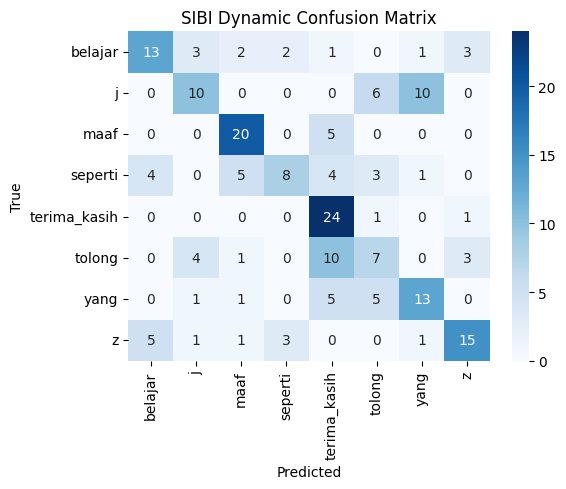

In [18]:
model = tf.keras.models.load_model(MODEL_PATH)
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=labels, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SIBI Dynamic Confusion Matrix')
plt.tight_layout()
plt.show()

In [19]:
# Export as TF SavedModel for the TFJS converter. We skip the legacy
# TFLite intermediate because tf.lite.TFLiteConverter crashes on LSTM
# layers in some TF 2.16+ envs (segfault, no stack trace).
# tensorflowjs_converter --input_format=tf_saved_model reads this directly.
model.export(SAVED_MODEL_DIR)
print(f'Wrote SavedModel to {SAVED_MODEL_DIR}/')

INFO:tensorflow:Assets written to: point_history_classifier_saved_model/assets


INFO:tensorflow:Assets written to: point_history_classifier_saved_model/assets


Saved artifact at 'point_history_classifier_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  124653844120144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124653578768048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124652543512064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124652544207584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124652544200720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124652544198432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124652543005920: TensorSpec(shape=(), dtype=tf.resource, name=None)
Wrote SavedModel to point_history_classifier_saved_model/
